# Introduction to Data Analysis with Python
### Health Data Research UK — COVID-19 Hospital Length of Stay Dataset

---

**Workshop outline (45 min)**

| # | Section | Time |
|---|---------|------|
| 1 | Load the data | 8 min |
| 2 | Explore & clean | 8 min |
| 3 | Visualise | 12 min |
| 4 | Ask a statistical question | 5 min |
| 5 | Your turn | 7 min |

---

**Dataset source:** [HDRUK/los_review](https://github.com/HDRUK/los_review) — data extracted from a systematic review of 100+ published studies on COVID-19 hospital length of stay (Rees et al., 2020, *BMC Medicine*).

Each row represents a **cohort** reported in a published paper. Variables include country, patient severity, age, sample size, and length of stay in days.

## From Excel to Python — a quick map

If you already use Excel for data analysis, here is how the familiar tools translate.
This notebook follows the same 7-step workflow described in the
[Data Analysis Workflow – Plant Growth Experiments](https://github.com/forest929/Data_Analysis_workfow_plant_growth)
guide, applied here to a clinical dataset. Steps 1–2 (collect & organise) were done
by the original researchers; we pick up at step 3.

| Step | Excel tool | Python equivalent | Notebook section |
|------|-----------|-------------------|-----------------|
| 3. Explore | Scroll / `Ctrl+End` | `df.head()`, `.shape` | Section 1 |
| 3. Explore | Pivot Table — count/mean | `df.groupby().mean()` | Section 2f |
| 3. Explore | Summary stats sidebar | `df.describe()` | Section 2e |
| 4. Clean | Filter blanks | `df.dropna()` | Section 2b |
| 4. Clean | Find & Replace | `.str.strip().str.lower()` | Section 2d |
| 4. Clean | Format as Date | `pd.to_datetime()` | *(bonus)* |
| 6. Quick check | Conditional formatting | Histogram / box plot | Section 3 |
| 6. Quick check | Insert Chart | `sns.boxplot()`, `plt.hist()` | Section 3 |
| 7. Statistics | `=T.TEST()` | `stats.mannwhitneyu()` | Section 4 |

> **Key difference:** In Excel, each action changes the file.
> In Python, you write a **script** — a reproducible set of instructions
> that runs identically on any dataset, on any machine, at any time.

## 0. Setup — import libraries

Python on its own is fairly minimal. **Libraries** (also called packages) extend it with new capabilities.

| Library | What it does |
|---------|-------------|
| `pandas` | Load and manipulate tabular data (think: powerful Excel) |
| `matplotlib` | Create charts and figures |
| `seaborn` | Higher-level, prettier statistical plots |
| `scipy` | Scientific computing — statistics, signal processing, etc. |

These are all **pre-installed in Google Colab** — no setup needed.

In [13]:
# If you are running this notebook locally (not in Google Colab), run this cell first.
# In Google Colab these packages are pre-installed — you can skip or ignore any 'already satisfied' messages.
!pip install pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Make plots look clean
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## 1. Load the Data

The dataset lives on GitHub. We can load it directly from the URL using `pandas` — no download needed.

> `pd.read_csv()` reads a comma-separated file (local path **or** URL) into a **DataFrame** — the core data structure in pandas, essentially a table with labelled rows and columns.

In [15]:
url = "https://raw.githubusercontent.com/HDRUK/los_review/master/data/LOS%20analysis%20dataset.csv"

df_raw = pd.read_csv(url)

print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")

Rows: 131
Columns: 76


### What columns do we have?

76 columns is a lot. Let's see all of them, then pick the ones relevant to our questions.

In [16]:
# Print all column names, numbered for readability
for i, col in enumerate(df_raw.columns):
    print(f"{i+1:>3}. {col}")

  1. StudyNo
  2. Extracted by
  3. Author
  4. date_published
  5. DOI
  6. Title
  7. date_first_admit
  8. date_last_admit
  9. date_fup
 10. Country
 11. Province
 12. City
 13. Study Population
 14. overlappingPopulation
 15. overlappingCluster
 16. overlappingInclude
 17. All patients discharged/ dead?
 18. Study design
 19. End point
 20. los_group
 21. Diseases status
 22. Disease status definition
 23. Treatment
 24. Treatment definition
 25. ICU definition (if applicable / available)
 26. age_group
 27. plot_cat
 28. covid_severity
 29. grouped_by_severity
 30. other_feature_comorbidity
 31. trt_group
 32. other_group
 33. outcome
 34. N
 35. perc_male
 36. perc_male_specific_for_group
 37. Age range
 38. age_med
 39. age_q25
 40. age_q75
 41. age_mean
 42. age_sd
 43. age_min
 44. age_max
 45. age_specific_for_group
 46. LOS (unspecified)
 47. LOS (non-ICU)
 48. LOS ICU
 49. LOS high flow nasal cannula
 50. Symptom onset to admission
 51. Symptom onset to discharge or death


### Preview the first few rows

In [17]:
# .head() shows the first 5 rows by default
df_raw.head(8)

,StudyNo,Extracted by,Author,date_published,DOI,Title,date_first_admit,date_last_admit,date_fup,Country,...,LOS_nonICU_q25,LOS_nonICU_q75,LOS_ICU_med,LOS_ICU_q25,LOS_ICU_q75,LOS_ICU_mean,LOS_ICU_sd,Issues/ biases with data,Notes,Included
0,1.0,Emily,Bhatraju et al.,30/03/2020,DOI: 10.1056/NEJMoa2004500,Covid-19 in Critically Ill Patients in the Sea...,24/02/2020,09/03/2020,23/03/2020,US,...,NaN,NaN,9.0,4.0,14.0,NaN,NaN,"12 (50%) had died, 4 (17%) had been discharged...",NaN,1
1,NaN,NaN,Bhatraju et al.,NaN,NaN,NaN,NaN,NaN,NaN,US,...,NaN,NaN,14.0,4.0,17.0,NaN,NaN,NaN,NaN,0
2,2.0,Yalda,Cai et al.,02/04/2020,https://doi.org/10.1111/all.14309,COVID-19 in a Designated Infectious Diseases H...,11/01/2020,06/02/2020,06/03/2020,China,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not all patients dead/discharge. ~10% missing....,1
3,NaN,NaN,Cai et al.,NaN,NaN,NaN,NaN,NaN,NaN,China,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,NaN,NaN,Cai et al.,NaN,NaN,NaN,NaN,NaN,NaN,China,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,3.0,Yalda,Cao et al.,18/03/2020,10.1056/NEJMoa2001282,A Trial of Lopinavir–Ritonavir in Adults Hospi...,18/01/2020,03/02/2020,03/02/2020,China,...,NaN,NaN,10.0,5.0,14.0,NaN,NaN,Righ censored - only followed up for 28 days. ...,NaN,1
6,NaN,NaN,Cao et al.,NaN,NaN,NaN,NaN,NaN,NaN,China,...,NaN,NaN,10.0,8.0,17.0,NaN,NaN,NaN,NaN,0
7,NaN,NaN,Cao et al.,NaN,NaN,NaN,NaN,NaN,NaN,China,...,NaN,NaN,10.0,4.0,14.0,NaN,NaN,NaN,NaN,0


> **Notice:** Some rows have a blank `StudyNo` and `Author`. These are sub-group rows belonging to the study above them (e.g., same study split by outcome: Alive vs Deceased). We'll filter those out to keep one row per study cohort.

---
## 2. Explore & Clean

### 2a. Select relevant columns

We focus on 10 columns that cover the key research questions: *Where? Who? How severe? How long?*

In [18]:
cols_to_keep = [
    "StudyNo",
    "Author",
    "date_published",
    "Country",
    "covid_severity",
    "outcome",
    "N",              # sample size
    "perc_male",      # % male patients
    "age_med",        # median patient age
    "LOS_med",        # median length of stay (days) — general ward
    "LOS_ICU_med",    # median ICU length of stay (days)
]

df = df_raw[cols_to_keep].copy()
print(df.shape)

(131, 11)


### 2b. Filter to one row per study cohort

Keep only rows where `Author` is not missing — this removes the blank sub-group rows.

In [19]:
df = df.dropna(subset=["Author"])

print(f"Rows after filtering: {len(df)}")
df.head()

Rows after filtering: 116


,StudyNo,Author,date_published,Country,covid_severity,outcome,N,perc_male,age_med,LOS_med,LOS_ICU_med
0,1.0,Bhatraju et al.,30/03/2020,US,All,All,24.0,63.00,NaN,12.0,9.0
1,NaN,Bhatraju et al.,NaN,US,All,Alive,12.0,63.00,NaN,17.0,14.0
2,2.0,Cai et al.,02/04/2020,China,All,All,298.0,48.66,47.5,20.5,NaN
3,NaN,Cai et al.,NaN,China,Non-severe,All,240.0,44.17,41.0,19.0,NaN
4,NaN,Cai et al.,NaN,China,Severe,All,58.0,67.24,62.5,27.0,NaN


### 2c. Check for missing values

Missing data is the reality of clinical research. Let's see where the gaps are.

In [20]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

pd.DataFrame({"Missing count": missing, "Missing %": missing_pct})

,Missing count,Missing %
StudyNo,64,55.2
Author,0,0.0
date_published,64,55.2
Country,2,1.7
covid_severity,0,0.0
outcome,0,0.0
N,1,0.9
perc_male,8,6.9
age_med,31,26.7
LOS_med,46,39.7


### 2d. Explore categorical variables

`value_counts()` tells us the frequency of each unique value — useful for understanding the composition of the dataset.

In [21]:
print("=== Country (top 10) ===")
print(df["Country"].value_counts().head(10))

print("\n=== COVID Severity ===")
print(df["covid_severity"].value_counts())

print("\n=== Outcome ===")
print(df["outcome"].value_counts())

=== Country (top 10) ===
Country
China                       101
Italy                         3
Worldwide (25 countries)      3
US                            2
UK                            2
EU/EEA                        2
USA                           1
Name: count, dtype: int64

=== COVID Severity ===
covid_severity
All           78
Severe        20
Non-severe    11
Mild           4
Moderate       3
Name: count, dtype: int64

=== Outcome ===
outcome
Alive    60
All      35
Dead     21
Name: count, dtype: int64


### 2e. Summary statistics

`.describe()` gives count, mean, std, min, quartiles, and max for every numeric column — a quick sanity check.

In [22]:
df[["N", "perc_male", "age_med", "LOS_med", "LOS_ICU_med"]].describe().round(1)

,N,perc_male,age_med,LOS_med,LOS_ICU_med
count,115.0,108.0,85.0,70.0,23.0
mean,198.1,55.2,54.7,15.6,9.2
std,434.9,12.1,12.6,7.2,3.1
min,1.0,0.0,2.0,4.8,5.0
25%,23.5,47.1,49.0,12.0,7.0
50%,65.0,55.1,57.0,14.0,9.0
75%,157.0,62.5,62.5,18.9,10.5
max,3316.0,82.0,76.0,53.0,19.0


### 2f. GroupBy — the Pivot Table equivalent

In Excel you would drag `covid_severity` to Rows and `LOS_med` to Values, then set
the aggregation to Average. In pandas, one line does the same:

In [23]:
# Equivalent of: Pivot Table → Rows: covid_severity | Values: mean(LOS_med)
los_by_severity = (
    df.groupby("covid_severity")["LOS_med"]
      .agg(count="count", mean="mean", median="median")
      .round(1)
      .sort_values("median", ascending=False)
)
print(los_by_severity)

                count  mean  median
covid_severity                     
Severe             10  24.0    21.5
Mild                2  17.5    17.5
All                52  14.2    13.0
Moderate            1  12.0    12.0
Non-severe          5  13.6    12.0


In [24]:
# Two-variable groupby: Country (top 5) × LOS_med + age_med
top5 = df["Country"].value_counts().head(5).index
df[df["Country"].isin(top5)].groupby("Country")[["LOS_med", "age_med"]].mean().round(1)

,LOS_med,age_med
Country,,
China,15.6,53.6
Italy,NaN,63.0
UK,NaN,60.0
US,14.5,NaN
Worldwide (25 countries),NaN,71.0


---
## 3. Visualise

### 3a. How many studies came from each country?

A simple bar chart — but already tells a story about where research was concentrated.

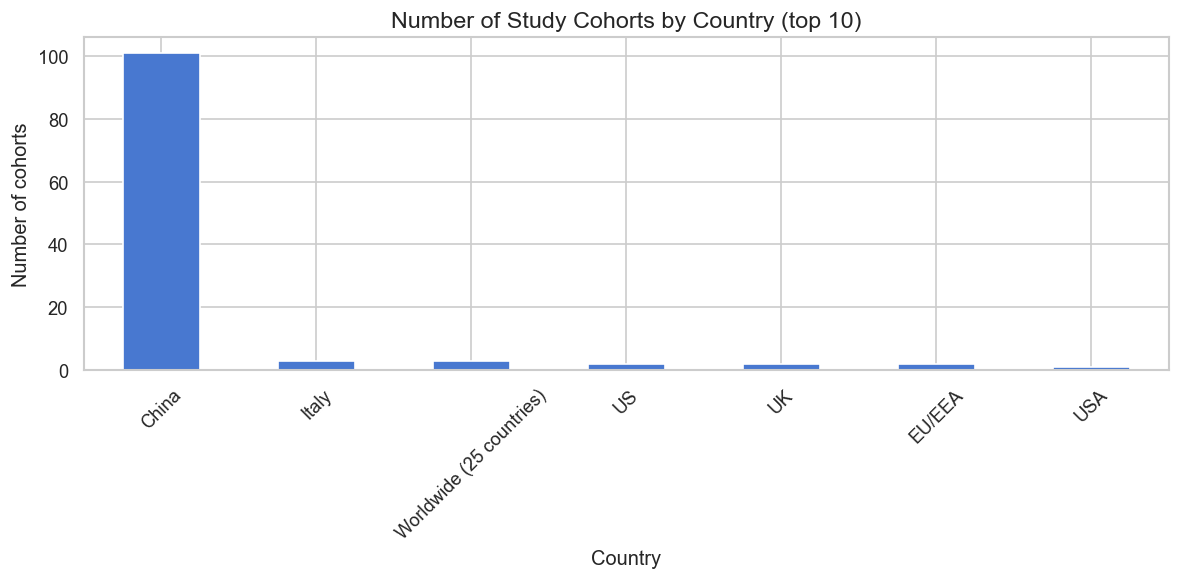

In [25]:
top_countries = df["Country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_countries.plot(kind="bar", ax=ax)

ax.set_title("Number of Study Cohorts by Country (top 10)", fontsize=14)
ax.set_xlabel("Country")
ax.set_ylabel("Number of cohorts")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3b. Distribution of hospital length of stay

A **histogram** shows the shape of the data — is it symmetric, skewed, bimodal?

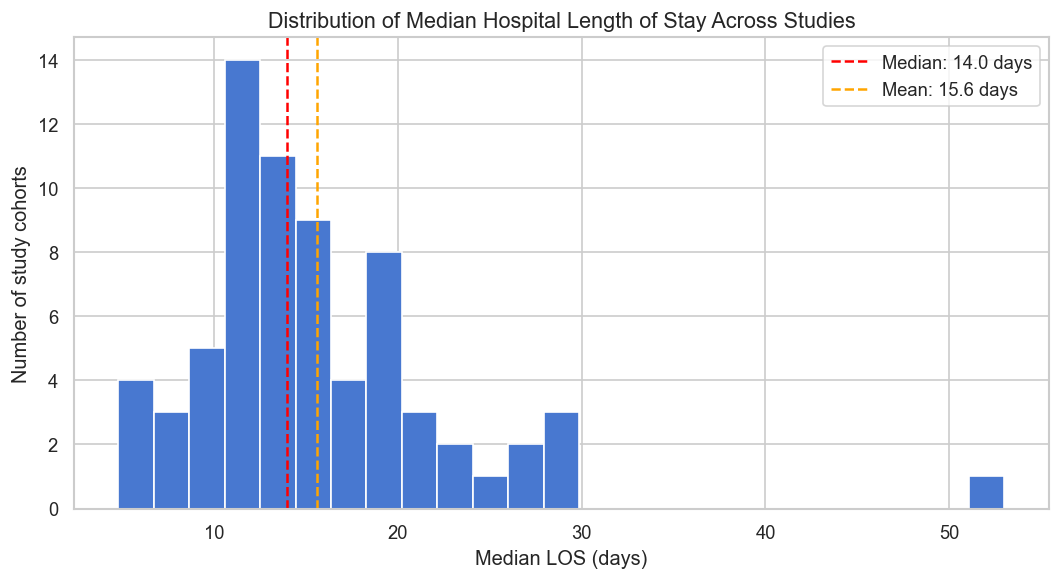

Range: 5 – 53 days


In [26]:
los_data = df["LOS_med"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(los_data, bins=25, edgecolor="white")

ax.axvline(los_data.median(), color="red", linestyle="--", label=f"Median: {los_data.median():.1f} days")
ax.axvline(los_data.mean(),   color="orange", linestyle="--", label=f"Mean: {los_data.mean():.1f} days")

ax.set_title("Distribution of Median Hospital Length of Stay Across Studies", fontsize=13)
ax.set_xlabel("Median LOS (days)")
ax.set_ylabel("Number of study cohorts")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Range: {los_data.min():.0f} – {los_data.max():.0f} days")

> **Interpretation:** When mean > median, the distribution is **right-skewed** — a small number of studies reported very long stays, pulling the mean up. This is typical of clinical LOS data.

### 3c. Does severity affect length of stay?

A **box plot** compares distributions across groups. Each box shows the interquartile range (25th–75th percentile), the line is the median, and dots are outliers.

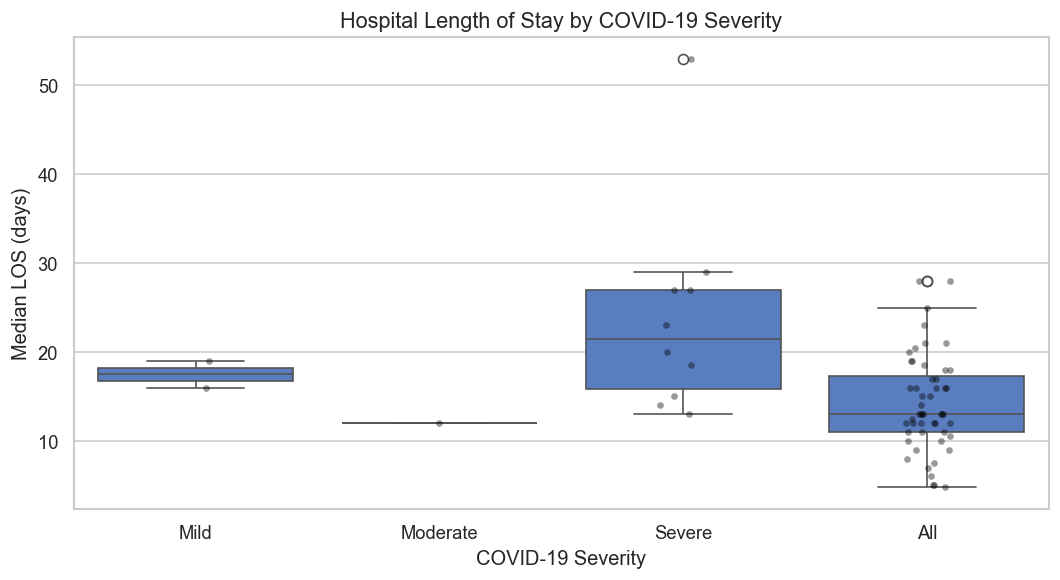

In [27]:
# Keep only the four most common severity categories
severity_order = ["Mild", "Moderate", "Severe", "All"]
df_sev = df[
    df["covid_severity"].isin(severity_order) &
    df["LOS_med"].notna()
]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df_sev,
    x="covid_severity", y="LOS_med",
    order=severity_order,
    ax=ax
)
sns.stripplot(
    data=df_sev,
    x="covid_severity", y="LOS_med",
    order=severity_order,
    color="black", alpha=0.4, size=4, ax=ax
)

ax.set_title("Hospital Length of Stay by COVID-19 Severity", fontsize=13)
ax.set_xlabel("COVID-19 Severity")
ax.set_ylabel("Median LOS (days)")

plt.tight_layout()
plt.show()

### 3d. Does sample size predict reported LOS?

A **scatter plot** explores the relationship between two continuous variables. We use a log scale on the x-axis because sample sizes span several orders of magnitude.

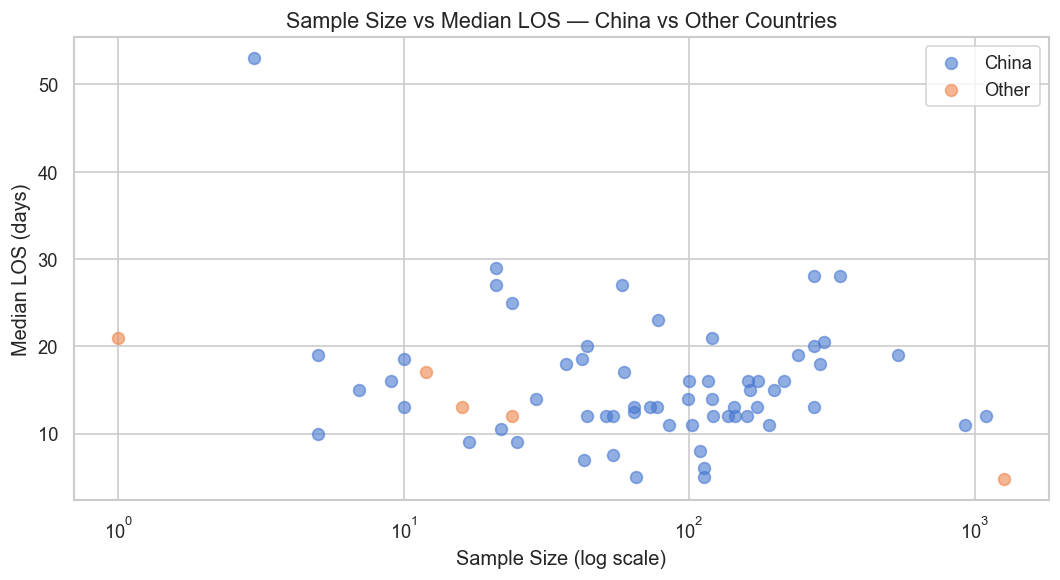

In [28]:
df_scatter = df[["N", "LOS_med", "Country"]].dropna()

# Colour-code China vs other countries
df_scatter["Region"] = df_scatter["Country"].apply(
    lambda c: "China" if c == "China" else "Other"
)

fig, ax = plt.subplots(figsize=(9, 5))
for region, group in df_scatter.groupby("Region"):
    ax.scatter(group["N"], group["LOS_med"], label=region, alpha=0.6, s=50)

ax.set_xscale("log")
ax.set_title("Sample Size vs Median LOS — China vs Other Countries", fontsize=13)
ax.set_xlabel("Sample Size (log scale)")
ax.set_ylabel("Median LOS (days)")
ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Ask a Statistical Question

**Question:** Did COVID-19 patients in China have a significantly different length of stay compared to patients in other countries?

China was the early epicentre of the pandemic — patient management, disease variants, and healthcare capacity were likely different.

**Test choice:** We use the **Mann-Whitney U test** (non-parametric) because:
- LOS is right-skewed (we saw this in the histogram)
- We're comparing medians, not assuming a normal distribution
- Sample sizes per group are modest

In [29]:
china_los = df[df["Country"] == "China"]["LOS_med"].dropna()
other_los = df[df["Country"] != "China"]["LOS_med"].dropna()

stat, p_value = stats.mannwhitneyu(china_los, other_los, alternative="two-sided")

print(f"China — n={len(china_los)}, median LOS = {china_los.median():.1f} days")
print(f"Other — n={len(other_los)}, median LOS = {other_los.median():.1f} days")
print(f"\nMann-Whitney U = {stat:.0f}")
print(f"p-value = {p_value:.4f}")

if p_value < 0.05:
    print("\nResult: Statistically significant difference (p < 0.05)")
else:
    print("\nResult: No statistically significant difference (p ≥ 0.05)")

China — n=63, median LOS = 14.0 days
Other — n=7, median LOS = 17.0 days

Mann-Whitney U = 192
p-value = 0.5760

Result: No statistically significant difference (p ≥ 0.05)


### Visualise the comparison

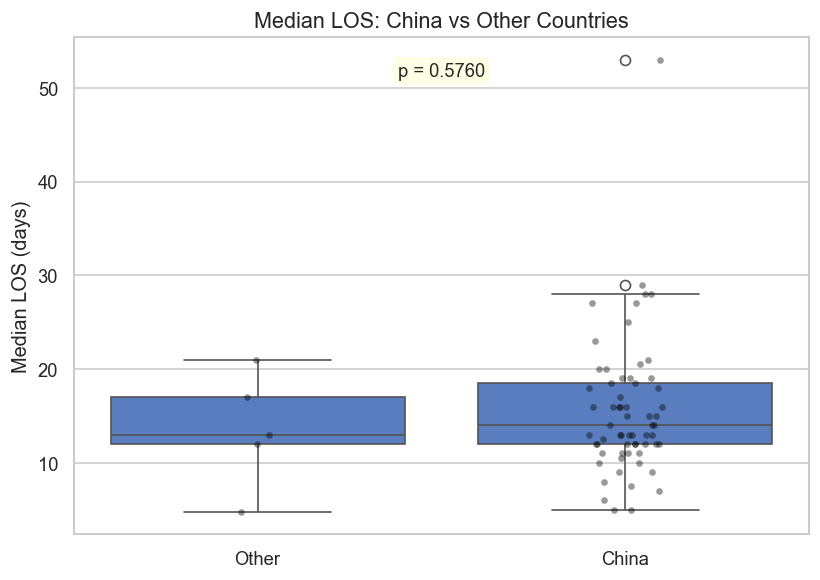

In [30]:
df_compare = df[["LOS_med", "Country"]].dropna().copy()
df_compare["Region"] = df_compare["Country"].apply(
    lambda c: "China" if c == "China" else "Other"
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_compare, x="Region", y="LOS_med", ax=ax)
sns.stripplot(data=df_compare, x="Region", y="LOS_med",
              color="black", alpha=0.4, size=4, ax=ax)

ax.set_title("Median LOS: China vs Other Countries", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Median LOS (days)")

# Annotate p-value
ax.text(0.5, 0.95, f"p = {p_value:.4f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

---
## 5. Your Turn!

Try these exercises on your own. Hints are provided — uncomment them if you get stuck.

---

### Exercise 1
**What is the median age of patients across all studies? What about only ICU studies?**

> Hint: Use `df["age_med"].median()` for all studies. For ICU studies, filter first on `df["LOS_ICU_med"].notna()`.

In [31]:
# Your code here


In [32]:
# --- HINT (uncomment to reveal) ---
# overall_age = df["age_med"].median()
# icu_age = df[df["LOS_ICU_med"].notna()]["age_med"].median()
# print(f"Overall median age: {overall_age:.1f} years")
# print(f"ICU studies median age: {icu_age:.1f} years")

---
### Exercise 2
**Create a bar chart showing the average (mean) LOS_med for each of the top 6 countries.**

> Hint: Use `df.groupby("Country")["LOS_med"].mean()` then sort and plot.

In [33]:
# Your code here


In [34]:
# --- HINT (uncomment to reveal) ---
# top6 = df["Country"].value_counts().head(6).index
# mean_los = df[df["Country"].isin(top6)].groupby("Country")["LOS_med"].mean().sort_values(ascending=False)
#
# fig, ax = plt.subplots(figsize=(9, 5))
# mean_los.plot(kind="bar", ax=ax)
# ax.set_title("Mean Reported LOS by Country (top 6)")
# ax.set_xlabel("Country")
# ax.set_ylabel("Mean of study-level median LOS (days)")
# ax.tick_params(axis="x", rotation=45)
# plt.tight_layout()
# plt.show()

---
### Exercise 3 (challenge)
**Is there a significant difference in LOS between studies reporting "Severe" patients vs "All" patients?**

> Hint: Filter `df` on `covid_severity`, extract `LOS_med`, run `stats.mannwhitneyu()`.

In [35]:
# Your code here


In [36]:
# --- HINT (uncomment to reveal) ---
# severe = df[df["covid_severity"] == "Severe"]["LOS_med"].dropna()
# all_pts = df[df["covid_severity"] == "All"]["LOS_med"].dropna()
#
# stat, p = stats.mannwhitneyu(severe, all_pts, alternative="two-sided")
# print(f"Severe — n={len(severe)}, median = {severe.median():.1f} days")
# print(f"All    — n={len(all_pts)}, median = {all_pts.median():.1f} days")
# print(f"p = {p:.4f}")

---
## 6. Next Steps & Resources

### Keep practising

| Resource | What it covers |
|----------|---------------|
| [Python for Everybody (Coursera)](https://www.coursera.org/specializations/python) | Python fundamentals, free to audit |
| [Kaggle Learn](https://www.kaggle.com/learn) | Pandas, data viz, ML — short hands-on courses |
| [The Carpentries](https://datacarpentry.org/lessons/) | Data analysis workshops designed for researchers |
| [Data Analysis Workflow – Plant Growth](https://github.com/forest929/Data_Analysis_workfow_plant_growth) | 7-step research workflow, Excel + Python side-by-side |
| [pandas documentation](https://pandas.pydata.org/docs/) | Reference and tutorials |

### Set up your local environment

```bash
# 1. Install Python via Anaconda (recommended for scientists)
#    https://www.anaconda.com/download

# 2. Install VS Code or PyCharm for a full IDE experience

# 3. Clone this workshop's repository
git clone https://github.com/HDRUK/los_review.git
```

### What to explore next with this dataset
- **Correlation:** Is older median age associated with longer LOS? (`df[["age_med","LOS_med"]].corr()`)
- **Time trend:** Did reported LOS change over the course of 2020? (parse `date_published`, plot LOS over time)
- **Regression:** Predict LOS from age + severity + country using `scikit-learn`

---
*Workshop materials: github.com/HDRUK/los_review | Rees et al. (2020) BMC Medicine*